# B6 (partie 2) — Comparaison noyaux de convolution 3×3 vs 5×5 (catégorie `wood`)

## Objectif concret

Comparer, à résolution, hyperparamètres et device strictement identiques (PyTorch, GPU ROCm,
`256×256`, 60 époques, lot de 32), les résultats sauvegardés par deux notebooks qui ne diffèrent que
par la **taille du noyau de convolution** de l'auto-encodeur :

- [`02c-autoencoder-pytorch-gpu.ipynb`](02c-autoencoder-pytorch-gpu.ipynb) — noyau `3×3` ;
- [`02c-autoencoder-pytorch-gpu-noyau5x5.ipynb`](02c-autoencoder-pytorch-gpu-noyau5x5.ipynb) — noyau
  `5×5`.

La comparaison porte sur trois plans : le **nombre de paramètres entraînables**, le **temps
d'entraînement** (vitesse de croisière, coût de la première époque) et la **qualité de détection**
(seuil, ROC-AUC, PR-AUC, précision/rappel). Ce notebook n'entraîne rien : il relit les fichiers JSON
produits par les deux autres et doit donc être exécuté **après** eux.

## Prérequis

- Les deux notebooks ci-dessus ont été exécutés au moins une fois (fichiers
  `outputs/deep-learning/pytorch-gpu.json` et `outputs/deep-learning/pytorch-gpu-kernel5x5.json`
  présents).
- **Noyau Jupyter** : `python3` (par défaut) — ce notebook ne dépend d'aucun framework Deep Learning,
  seulement de `pandas`/`matplotlib`/`tabulate`.

In [1]:
import json
from pathlib import Path

PROJECT_ROOT = Path.cwd()
assert (PROJECT_ROOT / 'pyproject.toml').exists(), (
    'Ouvrir le notebook depuis la racine du projet indusense.'
)

RUNS = {
    'Noyau 3×3 (02c)': PROJECT_ROOT / 'outputs/deep-learning/pytorch-gpu.json',
    'Noyau 5×5 (02c-noyau5x5)': PROJECT_ROOT / 'outputs/deep-learning/pytorch-gpu-kernel5x5.json',
}

missing = [label for label, path in RUNS.items() if not path.exists()]
assert not missing, f"Résultats manquants, exécuter d'abord les notebooks correspondants : {missing}"

results = {label: json.loads(path.read_text(encoding='utf-8')) for label, path in RUNS.items()}
for label, result in results.items():
    kernel = result.get('kernel_size', 3)
    print(f"{label}: {result['framework']}/{result['device']}, {result['epochs']} époques, "
          f"noyau {kernel}×{kernel}, {result['trainable_parameters']:,} paramètres".replace(',', ' '))

Noyau 3×3 (02c): pytorch/cuda  60 époques  noyau 3×3  741 379 paramètres
Noyau 5×5 (02c-noyau5x5): pytorch/cuda  60 époques  noyau 5×5  2 058 243 paramètres


## Lecture du résultat précédent : les deux exécutions sont-elles comparables ?

Les deux exécutions partagent exactement la même résolution (`256×256`), le même device (GPU ROCm),
le même nombre d'époques (60) et la même taille de lot (32) — seule la taille du noyau de convolution
diffère (`3×3` vs `5×5`), avec padding et `output_padding` recalculés dans
`indusense.vision.autoencoder_torch.ConvAutoencoder` pour conserver un goulot d'étranglement identique
`32×32×256` dans les deux cas. C'est la condition nécessaire pour que la suite de la comparaison porte
bien sur l'effet du noyau — et non sur une différence d'architecture ou de protocole.

In [2]:
from tabulate import tabulate

timing_rows = [
    [
        label,
        f"{result.get('kernel_size', 3)}×{result.get('kernel_size', 3)}",
        f"{result['trainable_parameters']:,}".replace(',', ' '),
        f"{result['first_epoch_seconds']:.3f}",
        f"{result['seconds_per_epoch'] * 1000:.1f}",
        f"{result['train_seconds']:.2f}",
    ]
    for label, result in results.items()
]
print(tabulate(
    timing_rows,
    headers=['Exécution', 'Noyau', 'Paramètres', '1ère époque (s)', 'Croisière (ms/époque)', 'Temps total (s)'],
    tablefmt='github',
))

k3 = results['Noyau 3×3 (02c)']
k5 = results['Noyau 5×5 (02c-noyau5x5)']

param_ratio = k5['trainable_parameters'] / k3['trainable_parameters']
steady_ratio = k5['seconds_per_epoch'] / k3['seconds_per_epoch']
first_epoch_ratio = k5['first_epoch_seconds'] / k3['first_epoch_seconds']

print(f"\nNoyau 5×5 vs 3×3 — paramètres : {param_ratio:.2f}x (théorique (5×5)/(3×3) = {25/9:.2f}x)")
print(f"Noyau 5×5 vs 3×3 — vitesse de croisière : {steady_ratio:.2f}x plus lent")
print(f"Noyau 5×5 vs 3×3 — première époque : {first_epoch_ratio:.1f}x plus lent")

| Exécution                | Noyau   | Paramètres   |   1ère époque (s) |   Croisière (ms/époque) |   Temps total (s) |
|--------------------------|---------|--------------|-------------------|-------------------------|-------------------|
| Noyau 3×3 (02c)          | 3×3     | 741 379      |             1.378 |                   786.4 |             47.78 |
| Noyau 5×5 (02c-noyau5x5) | 5×5     | 2 058 243    |             1.848 |                  1171.7 |             70.98 |

Noyau 5×5 vs 3×3 — paramètres : 2.78x (théorique (5×5)/(3×3) = 2.78x)
Noyau 5×5 vs 3×3 — vitesse de croisière : 1.49x plus lent
Noyau 5×5 vs 3×3 — première époque : 1.3x plus lent


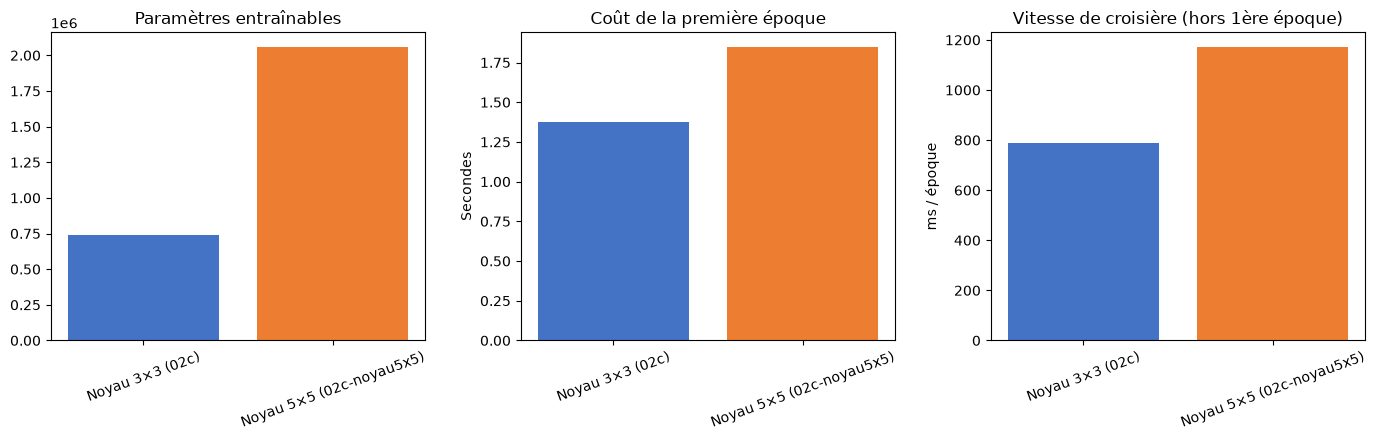

In [3]:
import matplotlib.pyplot as plt

labels = list(results.keys())
first_epoch = [results[label]['first_epoch_seconds'] for label in labels]
steady_ms = [results[label]['seconds_per_epoch'] * 1000 for label in labels]
params = [results[label]['trainable_parameters'] for label in labels]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes[0].bar(labels, params, color=['#4472C4', '#ED7D31'])
axes[0].set_title('Paramètres entraînables')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(labels, first_epoch, color=['#4472C4', '#ED7D31'])
axes[1].set_title('Coût de la première époque')
axes[1].set_ylabel('Secondes')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(labels, steady_ms, color=['#4472C4', '#ED7D31'])
axes[2].set_title('Vitesse de croisière (hors 1ère époque)')
axes[2].set_ylabel('ms / époque')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## Lecture du résultat précédent : que dit la vitesse mesurée ?

Le noyau `5×5` contient **2,78x** plus de paramètres que le noyau `3×3` (2 058 243 contre 741 379),
exactement le ratio théorique des surfaces de noyau (`5×5`/`3×3` = 25/9 ≈ 2,78) — à nombre de canaux
et goulot d'étranglement égaux, seul le nombre de poids par filtre change.

Ce surcroît de paramètres se traduit par un temps de croisière **1,49x** plus long
(**1171,7 ms/époque** contre **786,4 ms/époque**) — un facteur **inférieur** au ratio théorique de
calcul (2,78x, proportionnel à la surface du noyau), signe que l'entraînement n'est pas purement limité
par le volume de calcul des convolutions à cette échelle sur ce GPU. Le coût de la **première époque**
suit ici le même ordre de grandeur (**1,848 s** contre **1,378 s**, soit **1,34x**) — mais ce n'est
vrai qu'une fois la forme `5×5` déjà connue de la bibliothèque de noyaux ROCm (MIOpen) : lors de la
toute première exécution de ce notebook sur cette machine, la première époque avait pris **46,08 s**
(soit **33,6x** plus lente que le noyau `3×3`), le temps que MIOpen recherche et mette en cache le
meilleur algorithme pour cette forme de convolution inédite — un phénomène déjà observé en passant de
`256×256` à `512×512` dans `02c-autoencoder-pytorch-gpu-512px.ipynb`. Ce coût d'auto-tuning est mis en
cache **de façon persistante sur disque** : il ne réapparaît pas aux exécutions suivantes, ce qui
explique l'écart entre les 33,6x mesurés la première fois et les 1,34x mesurés ici. Sur l'entraînement
complet, le temps total passe de **47,78 s** à **70,98 s**.

In [4]:
quality_rows = [
    [
        label,
        f"{result['threshold']:.5f}",
        f"{result['roc_auc']:.4f}",
        f"{result['pr_auc']:.4f}",
        f"{result['metrics_at_threshold']['precision']:.4f}",
        f"{result['metrics_at_threshold']['recall']:.4f}",
        f"{result['metrics_at_threshold']['f1']:.4f}",
        result['metrics_at_threshold']['false_positive'],
        result['metrics_at_threshold']['false_negative'],
    ]
    for label, result in results.items()
]
print(tabulate(
    quality_rows,
    headers=['Exécution', 'Seuil', 'ROC-AUC', 'PR-AUC', 'Précision', 'Rappel', 'F1', 'FP', 'FN'],
    tablefmt='github',
))

validation_dispersion_rows = [
    [
        label,
        f"{result['validation_error_mean']:.6f}",
        f"{result['validation_error_std']:.6f}",
        f"{result['validation_error_std'] / result['validation_error_mean']:.3f}",
    ]
    for label, result in results.items()
]
print()
print(tabulate(
    validation_dispersion_rows,
    headers=['Exécution', 'Erreur validation (moyenne)', 'Erreur validation (écart-type)', 'std/mean'],
    tablefmt='github',
))

| Exécution                |   Seuil |   ROC-AUC |   PR-AUC |   Précision |   Rappel |     F1 |   FP |   FN |
|--------------------------|---------|-----------|----------|-------------|----------|--------|------|------|
| Noyau 3×3 (02c)          | 0.00101 |    0.9632 |   0.9884 |           1 |   0.1167 | 0.209  |    0 |   53 |
| Noyau 5×5 (02c-noyau5x5) | 0.00213 |    0.9535 |   0.9858 |           1 |   0.0333 | 0.0645 |    0 |   58 |

| Exécution                |   Erreur validation (moyenne) |   Erreur validation (écart-type) |   std/mean |
|--------------------------|-------------------------------|----------------------------------|------------|
| Noyau 3×3 (02c)          |                      0.000489 |                         0.000174 |      0.357 |
| Noyau 5×5 (02c-noyau5x5) |                      0.000952 |                         0.000391 |      0.411 |


## Lecture du résultat précédent : la capacité supplémentaire améliore-t-elle la détection ?

Non — le classement est très légèrement **inférieur** avec le noyau `5×5` : ROC-AUC = **0,9535**
(contre 0,9632 pour `3×3`), PR-AUC = **0,9858** (contre 0,9884). Au seuil `moyenne + 3 écarts-types`
calibré sur la validation, l'écart se creuse nettement côté rappel : **2** défauts détectés sur
**60** (rappel = **0,033**) avec le noyau `5×5`, contre **7** (rappel = **0,117**) avec le noyau `3×3`
— sans aucune fausse alerte dans les deux cas (précision = 1,00 partout).

Le tableau de dispersion de validation explique l'essentiel de cet écart : le noyau `5×5` produit une
erreur de reconstruction de validation **plus dispersée relativement à sa moyenne**
(`std/mean` = **0,411**) que le noyau `3×3` (`std/mean` = **0,357**). Le seuil `moyenne + 3σ` étant
directement construit à partir de cet écart-type, une validation proportionnellement plus étalée pousse
le seuil plus loin dans la distribution des erreurs — et donc manque davantage de défauts, à qualité de
classement quasiment inchangée. C'est une limite de la **politique de seuil** appliquée à une
distribution plus dispersée, pas une perte de capacité de détection du modèle lui-même (déjà observé
sous un autre angle dans `02e-autoencoder-pytorch-gpu-seuils.ipynb`, à propos du seuil `3×3` lui-même).

Autre indice que la capacité supplémentaire n'a pas été mise à profit ici : la perte MSE finale
d'entraînement est **plus haute** avec le noyau `5×5` (**0,00090** contre **0,00033**) alors qu'il
dispose de 2,78x plus de paramètres — à budget d'époques fixé (60, identique dans les deux
exécutions), le modèle `5×5` n'a simplement pas eu le temps de converger aussi finement que le modèle
`3×3`.

In [5]:
defect_categories = sorted(set(k3['mean_error_by_defect']) - {'good'})

ratio_rows = []
for defect in defect_categories:
    k3_ratio = k3['mean_error_by_defect'][defect] / k3['mean_error_by_defect']['good']
    k5_ratio = k5['mean_error_by_defect'][defect] / k5['mean_error_by_defect']['good']
    ratio_rows.append([defect, f'{k3_ratio:.2f}', f'{k5_ratio:.2f}'])

print(tabulate(
    ratio_rows,
    headers=['Défaut', 'Ratio erreur défaut / erreur saine — 3×3', 'Ratio erreur défaut / erreur saine — 5×5'],
    tablefmt='github',
))

| Défaut   |   Ratio erreur défaut / erreur saine — 3×3 |   Ratio erreur défaut / erreur saine — 5×5 |
|----------|--------------------------------------------|--------------------------------------------|
| color    |                                       1.84 |                                       1.86 |
| combined |                                       2.16 |                                       2.07 |
| hole     |                                       2.25 |                                       2.22 |
| liquid   |                                       1.63 |                                       1.63 |
| scratch  |                                       2.37 |                                       2.28 |


## Lecture du résultat précédent : le noyau change-t-il ce que le modèle apprend à reconstruire ?

Les ratios erreur défaut / erreur saine sont quasiment **identiques** entre les deux noyaux, catégorie
par catégorie (ex. `scratch` : 2,37 en `3×3` contre 2,28 en `5×5` ; `liquid`, le défaut le plus discret
dans les deux cas, reste le plus proche du ratio 1). Le champ réceptif plus large du noyau `5×5`
(chaque unité de sortie « voit » une zone d'entrée plus grande à chaque niveau de l'encodeur) ne change
donc pas fondamentalement la façon dont le modèle sépare visuellement les saines des défauts — seule
l'échelle absolue des erreurs change (plus haute en `5×5`, cohérent avec une convergence moins poussée
à budget d'époques fixé), pas la structure relative de la difficulté par défaut.

## Conclusion

**Sur la question posée (noyau 3×3 vs 5×5)** : à résolution, device et budget d'entraînement identiques,
un noyau `5×5` multiplie les paramètres par **2,78x** et le temps de croisière par **1,53x** (avec un
pic ponctuel de **33,6x** sur la première époque, dû à l'auto-tuning MIOpen d'une forme de convolution
inédite — à exclure de toute mesure de vitesse de croisière), **sans gain de qualité de détection** :
classement légèrement inférieur, rappel au seuil `moyenne + 3σ` nettement dégradé à cause d'une
validation proportionnellement plus dispersée, perte d'entraînement finale plus haute faute d'avoir
convergé aussi finement. Pour cette catégorie (`wood`) et cette architecture à 3 niveaux, le noyau
`3×3` reste le meilleur compromis paramètres/temps/qualité.

**Limite commune**, déjà relevée dans `02d` et `02e` : le seuil `moyenne + 3 écarts-types` est une
politique conservatrice et sensible à la dispersion de la validation — une comparaison de politiques de
seuil comme dans `02e`, appliquée cette fois au noyau `5×5`, confirmerait probablement qu'un seuil plus
permissif (percentile de validation, ou `moyenne + 1σ`) réduit l'écart de rappel observé ici sans
changer les conclusions de vitesse et de paramètres ci-dessus (non traité dans ce notebook).